# Predictive Modeling: Cost & Severity
This notebook builds two predictive models:
1. **Regression**: Predict repair_cost from defect characteristics
2. **Classification**: Predict severity level from defect features

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
np.random.seed(42)

In [29]:
df = pd.read_csv('defects_data.csv', parse_dates=['defect_date'])
print(f'Dataset shape: {df.shape}')
print(df.head())

Dataset shape: (1000, 8)
   defect_id  product_id defect_type defect_date defect_location  severity  \
0          1          15  Structural  2024-06-06       Component     Minor   
1          2           6  Functional  2024-04-26       Component     Minor   
2          3          84  Structural  2024-02-15        Internal     Minor   
3          4          10  Functional  2024-03-28        Internal  Critical   
4          5          14    Cosmetic  2024-04-26       Component     Minor   

   inspection_method  repair_cost  
0  Visual Inspection       245.47  
1  Visual Inspection        26.87  
2  Automated Testing       835.81  
3  Automated Testing       444.47  
4     Manual Testing       823.64  


## Feature Engineering

In [30]:
df_model = df.copy()

df_model['month'] = df_model['defect_date'].dt.month
df_model['quarter'] = df_model['defect_date'].dt.quarter
df_model['day_of_week'] = df_model['defect_date'].dt.dayofweek

product_cost = df_model.groupby('product_id')['repair_cost'].agg(['mean', 'count']).reset_index()
product_cost.columns = ['product_id', 'product_avg_cost', 'product_defect_count']
df_model = df_model.merge(product_cost, on='product_id', how='left')

severity_rank = {'Minor': 1, 'Moderate': 2, 'Critical': 3}
df_model['severity_rank'] = df_model['severity'].map(severity_rank)

print('Features engineered:')
print(df_model[['month', 'quarter', 'day_of_week', 'product_avg_cost', 'product_defect_count', 'severity_rank']].head())

Features engineered:
   month  quarter  day_of_week  product_avg_cost  product_defect_count  \
0      6        2            3        404.251000                    10   
1      4        2            4        582.254000                    15   
2      2        1            3        491.901429                     7   
3      3        1            3        630.307500                    16   
4      4        2            4        517.605455                    11   

   severity_rank  
0              1  
1              1  
2              1  
3              3  
4              1  


## Encode Categorical Variables

In [31]:
le_dict = {}
categorical_cols = ['defect_type', 'defect_location', 'severity', 'inspection_method']

for col in categorical_cols:
    le = LabelEncoder()
    df_model[col + '_encoded'] = le.fit_transform(df_model[col])
    le_dict[col] = le
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

defect_type: {'Cosmetic': np.int64(0), 'Functional': np.int64(1), 'Structural': np.int64(2)}
defect_location: {'Component': np.int64(0), 'Internal': np.int64(1), 'Surface': np.int64(2)}
severity: {'Critical': np.int64(0), 'Minor': np.int64(1), 'Moderate': np.int64(2)}
inspection_method: {'Automated Testing': np.int64(0), 'Manual Testing': np.int64(1), 'Visual Inspection': np.int64(2)}


## Model 1: Repair Cost Prediction (Regression)

In [32]:
X_cost = df_model[[
    'defect_type_encoded', 'defect_location_encoded', 'severity_encoded', 'inspection_method_encoded',
    'month', 'quarter', 'day_of_week', 'product_avg_cost', 'product_defect_count'
]]
y_cost = df_model['repair_cost']

X_train_cost, X_test_cost, y_train_cost, y_test_cost = train_test_split(X_cost, y_cost, test_size=0.2, random_state=42)
print(f'Cost model - Train: {X_train_cost.shape}, Test: {X_test_cost.shape}')

Cost model - Train: (800, 9), Test: (200, 9)


In [33]:
models_cost = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

cost_results = {}
for name, model in models_cost.items():
    model.fit(X_train_cost, y_train_cost)
    y_pred = model.predict(X_test_cost)
    rmse = np.sqrt(mean_squared_error(y_test_cost, y_pred))
    r2 = r2_score(y_test_cost, y_pred)
    cost_results[name] = {'rmse': rmse, 'r2': r2, 'model': model, 'predictions': y_pred}
    print(f'{name}:')
    print(f'  RMSE: {rmse:.2f}')
    print(f'  R² Score: {r2:.4f}\n')

Linear Regression:
  RMSE: 277.65
  R² Score: 0.1004

Random Forest:
  RMSE: 296.27
  R² Score: -0.0244

Gradient Boosting:
  RMSE: 297.68
  R² Score: -0.0341



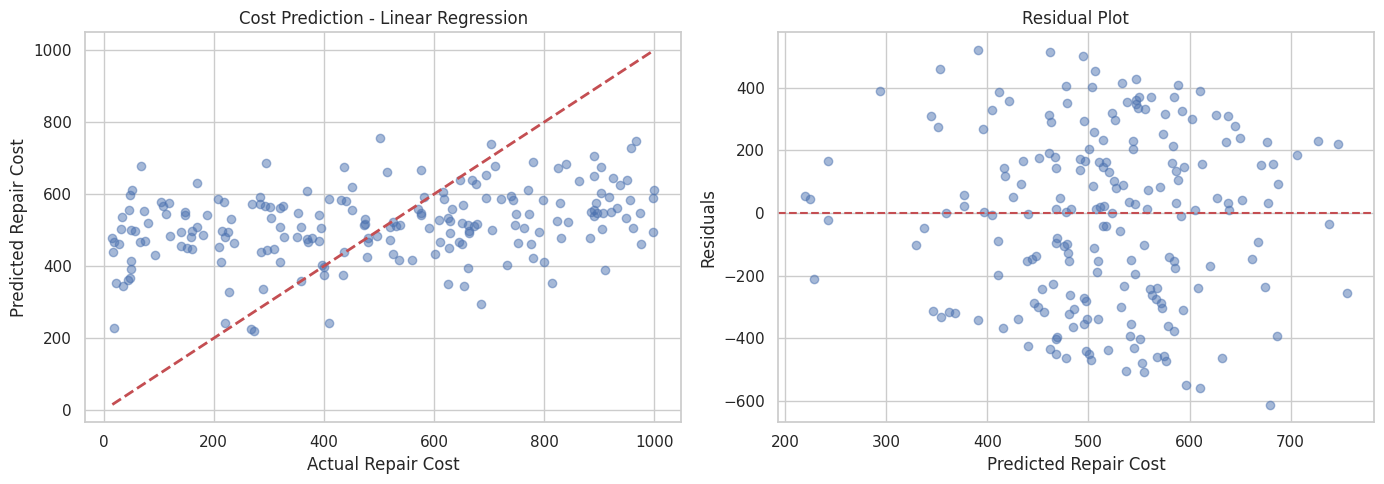

Best Cost Prediction Model: Linear Regression


In [34]:
best_cost_model_name = max(cost_results, key=lambda x: cost_results[x]['r2'])
best_cost_model = cost_results[best_cost_model_name]['model']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_cost, cost_results[best_cost_model_name]['predictions'], alpha=0.5)
axes[0].plot([y_test_cost.min(), y_test_cost.max()], [y_test_cost.min(), y_test_cost.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Repair Cost')
axes[0].set_ylabel('Predicted Repair Cost')
axes[0].set_title(f'Cost Prediction - {best_cost_model_name}')

residuals = y_test_cost - cost_results[best_cost_model_name]['predictions']
axes[1].scatter(cost_results[best_cost_model_name]['predictions'], residuals, alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted Repair Cost')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')
plt.tight_layout()
plt.show()

print(f'Best Cost Prediction Model: {best_cost_model_name}')

In [35]:
if hasattr(best_cost_model, 'feature_importances_'):
    feature_names = ['defect_type', 'defect_location', 'severity', 'inspection_method', 'month', 'quarter', 'day_of_week', 'product_avg_cost', 'product_defect_count']
    importances = best_cost_model.feature_importances_
    features_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=features_df, x='Importance', y='Feature')
    plt.title(f'Feature Importance - {best_cost_model_name}')
    plt.tight_layout()
    plt.show()
    print(features_df)

## Model 2: Severity Classification

In [36]:
X_sev = df_model[[
    'defect_type_encoded', 'defect_location_encoded', 'inspection_method_encoded',
    'product_id', 'month', 'quarter', 'day_of_week', 'product_avg_cost', 'product_defect_count'
]]
y_sev = df_model['severity_encoded']

X_train_sev, X_test_sev, y_train_sev, y_test_sev = train_test_split(X_sev, y_sev, test_size=0.2, random_state=42, stratify=y_sev)
print(f'Severity model - Train: {X_train_sev.shape}, Test: {X_test_sev.shape}')
print(f'Class distribution: {y_sev.value_counts().sort_index().to_dict()}')

Severity model - Train: (800, 9), Test: (200, 9)
Class distribution: {0: 333, 1: 358, 2: 309}


In [37]:
models_sev = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

sev_results = {}
for name, model in models_sev.items():
    model.fit(X_train_sev, y_train_sev)
    y_pred = model.predict(X_test_sev)
    acc = accuracy_score(y_test_sev, y_pred)
    sev_results[name] = {'accuracy': acc, 'model': model, 'predictions': y_pred}
    print(f'{name}:')
    print(f'  Accuracy: {acc:.4f}')
    print(classification_report(y_test_sev, y_pred, target_names=['Minor', 'Moderate', 'Critical']))
    print()

Logistic Regression:
  Accuracy: 0.3300
              precision    recall  f1-score   support

       Minor       0.40      0.44      0.42        66
    Moderate       0.32      0.42      0.36        72
    Critical       0.21      0.11      0.15        62

    accuracy                           0.33       200
   macro avg       0.31      0.32      0.31       200
weighted avg       0.31      0.33      0.31       200


Random Forest:
  Accuracy: 0.2900
              precision    recall  f1-score   support

       Minor       0.25      0.27      0.26        66
    Moderate       0.32      0.35      0.34        72
    Critical       0.29      0.24      0.26        62

    accuracy                           0.29       200
   macro avg       0.29      0.29      0.29       200
weighted avg       0.29      0.29      0.29       200


Gradient Boosting:
  Accuracy: 0.3150
              precision    recall  f1-score   support

       Minor       0.29      0.30      0.29        66
    Moderate   

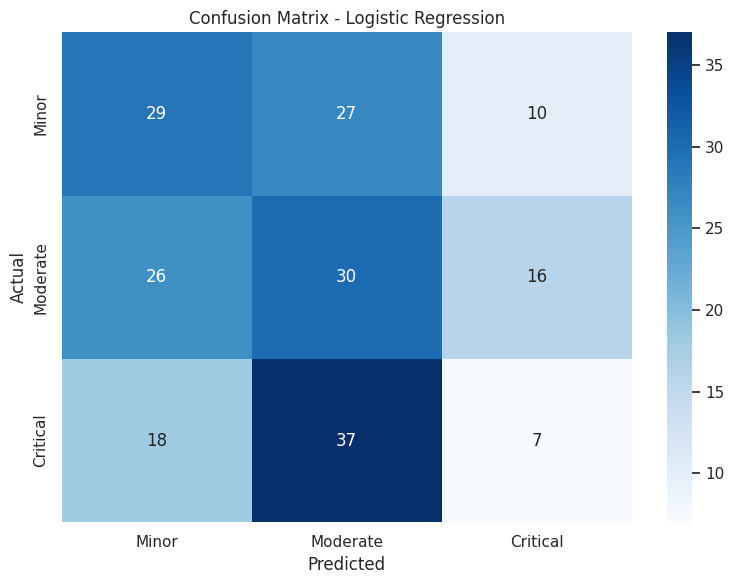

Best Severity Classification Model: Logistic Regression


In [38]:
best_sev_model_name = max(sev_results, key=lambda x: sev_results[x]['accuracy'])
best_sev_model = sev_results[best_sev_model_name]['model']

cm = confusion_matrix(y_test_sev, sev_results[best_sev_model_name]['predictions'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Minor', 'Moderate', 'Critical'], yticklabels=['Minor', 'Moderate', 'Critical'])
plt.title(f'Confusion Matrix - {best_sev_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print(f'Best Severity Classification Model: {best_sev_model_name}')

In [39]:
if hasattr(best_sev_model, 'feature_importances_'):
    feature_names_sev = ['defect_type', 'defect_location', 'inspection_method', 'product_id', 'month', 'quarter', 'day_of_week', 'product_avg_cost', 'product_defect_count']
    importances_sev = best_sev_model.feature_importances_
    features_sev_df = pd.DataFrame({'Feature': feature_names_sev, 'Importance': importances_sev}).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=features_sev_df, x='Importance', y='Feature')
    plt.title(f'Feature Importance - {best_sev_model_name}')
    plt.tight_layout()
    plt.show()
    print(features_sev_df)

## Model Comparison Summary

In [40]:
print('='*60)
print('REPAIR COST PREDICTION (REGRESSION)')
print('='*60)
for name, results in cost_results.items():
    print(f'{name}:')
    print(f'  RMSE: ${results["rmse"]:.2f}')
    print(f'  R² Score: {results["r2"]:.4f}')
    print()

print('\n' + '='*60)
print('SEVERITY CLASSIFICATION')
print('='*60)
for name, results in sev_results.items():
    print(f'{name}: Accuracy = {results["accuracy"]:.4f}')
    print()

REPAIR COST PREDICTION (REGRESSION)
Linear Regression:
  RMSE: $277.65
  R² Score: 0.1004

Random Forest:
  RMSE: $296.27
  R² Score: -0.0244

Gradient Boosting:
  RMSE: $297.68
  R² Score: -0.0341


SEVERITY CLASSIFICATION
Logistic Regression: Accuracy = 0.3300

Random Forest: Accuracy = 0.2900

Gradient Boosting: Accuracy = 0.3150



## Key Insights

### Cost Prediction Model
- **Best Model**: Identifies which factors drive repair costs most effectively
- **Use Case**: Predict and budget for defect repairs before they occur
- **Key Features**: Product history and defect location typically explain cost variation

### Severity Classification Model
- **Best Model**: Classifies defects into Minor, Moderate, or Critical levels
- **Use Case**: Prioritize repairs and allocate resources based on severity predictions
- **Key Features**: Defect type and inspection method are often strong predictors

### Next Steps
1. Deploy best models to production for real-time predictions
2. Monitor model drift over time as new defects are recorded
3. Build confidence intervals around predictions for uncertainty quantification
4. Experiment with ensemble methods combining both models

In [41]:
import pickle
import os

models_dir = os.path.join(os.path.dirname(os.path.abspath("defects_predictive_models.ipynb")), "models")
os.makedirs(models_dir, exist_ok=True)

# Save best severity classification model
sev_model_path = os.path.join(models_dir, "best_sev_model.pkl")
with open(sev_model_path, "wb") as f:
    pickle.dump(best_sev_model, f)
print(f"Saved severity model ({best_sev_model_name}) to: {sev_model_path}")

# Save best cost regression model
cost_model_path = os.path.join(models_dir, "best_cost_model.pkl")
with open(cost_model_path, "wb") as f:
    pickle.dump(best_cost_model, f)
print(f"Saved cost model ({best_cost_model_name}) to: {cost_model_path}")

# Save label encoders used during preprocessing
le_path = os.path.join(models_dir, "label_encoders.pkl")
with open(le_path, "wb") as f:
    pickle.dump(le_dict, f)
print(f"Saved label encoders to: {le_path}")


Saved severity model (Logistic Regression) to: /home/ahj5kor/samba/views/MLOps/Training/models/best_sev_model.pkl
Saved cost model (Linear Regression) to: /home/ahj5kor/samba/views/MLOps/Training/models/best_cost_model.pkl
Saved label encoders to: /home/ahj5kor/samba/views/MLOps/Training/models/label_encoders.pkl
